# 🔵 Colab E-iv — TensorFlow Sequential / High-Level API
**Sequential → compile → fit → evaluate → predict**

In [1]:
import tensorflow as tf, numpy as np, matplotlib.pyplot as plt
tf.random.set_seed(42); np.random.seed(42)
print('TF:', tf.__version__)

TF: 2.19.0


## 📊 Section 1 — Data

In [2]:
N=1000
x1=np.random.uniform(-2,2,(N,1)); x2=np.random.uniform(-2,2,(N,1)); x3=np.random.uniform(-2,2,(N,1))
y=2*x1**2+3*x2*x3+np.sin(x1*x2)+0.5*x3**2+np.random.normal(0,0.1,(N,1))
X=np.hstack([x1,x2,x3])
X_n=(X-X.mean(0))/X.std(0); y_mean,y_std=float(y.mean()),float(y.std()); y_n=(y-y_mean)/y_std
sp=int(0.8*N)
Xtr,Xte=X_n[:sp].astype('float32'),X_n[sp:].astype('float32')
Ytr,Yte=y_n[:sp].astype('float32'),y_n[sp:].astype('float32')

## 🏗️ Section 2 — Sequential Model

In [3]:
# Sequential: pass a list of layers — most concise Keras style
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu',  kernel_initializer='he_normal', input_shape=(3,)),
    tf.keras.layers.Dense(32, activation='relu',  kernel_initializer='he_normal'),
    tf.keras.layers.Dense(16, activation='tanh'),
    tf.keras.layers.Dense(1)
], name='sequential_regression')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_regression"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

## 🏋️ Section 3 — compile + fit + Callbacks

In [4]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='mse',
    metrics=['mae', 'mse']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=60,
                                      restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                          patience=30, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('best_sequential.h5', monitor='val_loss',
                                        save_best_only=True, verbose=0)
]

history = model.fit(
    Xtr, Ytr,
    epochs=1000, batch_size=64,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/1000
 1/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - loss: 2.9732 - mae: 1.3227 - mse: 2.9732

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 1.7910 - mae: 1.0059 - mse: 1.7910 - val_loss: 0.8754 - val_mae: 0.7127 - val_mse: 0.8754 - learning_rate: 0.0010
Epoch 2/1000
 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1.2752 - mae: 0.8177 - mse: 1.2752

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.8286 - mae: 0.6804 - mse: 0.8286 - val_loss: 0.4671 - val_mae: 0.5175 - val_mse: 0.4671 - learning_rate: 0.0010
Epoch 3/1000
 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.6928 - mae: 0.5996 - mse: 0.6928

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4569 - mae: 0.4975 - mse: 0.4569 - val_loss: 0.2785 - val_mae: 0.4090 - val_mse: 0.2785 - learning_rate: 0.0010
Epoch 4/1000
 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.4097 - mae: 0.4395 - mse: 0.4097

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2834 - mae: 0.3846 - mse: 0.2834 - val_loss: 0.1903 - val_mae: 0.3307 - val_mse: 0.1903 - learning_rate: 0.0010
Epoch 5/1000
 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.2741 - mae: 0.3753 - mse: 0.2741

...

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0021 - mae: 0.0352 - mse: 0.0021 - val_loss: 0.0077 - val_mae: 0.0631 - val_mse: 0.0077 - learning_rate: 0.0010
Epoch 361/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0022 - mae: 0.0364 - mse: 0.0022 - val_loss: 0.0082 - val_mae: 0.0669 - val_mse: 0.0082 - learning_rate: 0.0010
Epoch 362/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0024 - mae: 0.0373 - mse: 0.0024 - val_loss: 0.0099 - val_mae: 0.0765 - val_mse: 0.0099 - learning_rate: 0.0010
Epoch 363/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0030 - mae: 0.0427 - mse: 0.0030 - val_loss: 0.0107 - val_mae: 0.0801 - val_mse: 0.0107 - learning_rate: 0.0010
Epoch 364/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0042 - mae: 0.0511 - mse: 0.0042 - val_loss: 0.0090 - val_mae: 0.0705 - val_mse: 0.0090 - learning_rate: 0.0010
Epoch 365/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0054 - mae: 0.0543 - mse: 0.0054 - val_loss: 0.0092 - val_mae: 0.

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0039 - mae: 0.0483 - mse: 0.0039 - val_loss: 0.0071 - val_mae: 0.0632 - val_mse: 0.0071 - learning_rate: 0.0010
Epoch 370/1000
 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0035 - mae: 0.0452 - mse: 0.0035

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0036 - mae: 0.0445 - mse: 0.0036 - val_loss: 0.0070 - val_mae: 0.0613 - val_mse: 0.0070 - learning_rate: 0.0010
Epoch 371/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0024 - mae: 0.0380 - mse: 0.0024 - val_loss: 0.0080 - val_mae: 0.0648 - val_mse: 0.0080 - learning_rate: 0.0010
Epoch 372/1000
 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0030 - mae: 0.0434 - mse: 0.0030

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0025 - mae: 0.0384 - mse: 0.0025 - val_loss: 0.0069 - val_mae: 0.0610 - val_mse: 0.0069 - learning_rate: 0.0010
Epoch 373/1000
 1/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0028 - mae: 0.0425 - mse: 0.0028

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0024 - mae: 0.0379 - mse: 0.0024 - val_loss: 0.0065 - val_mae: 0.0595 - val_mse: 0.0065 - learning_rate: 0.0010
Epoch 374/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0019 - mae: 0.0333 - mse: 0.0019 - val_loss: 0.0069 - val_mae: 0.0608 - val_mse: 0.0069 - learning_rate: 0.0010
Epoch 375/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0017 - mae: 0.0318 - mse: 0.0017 - val_loss: 0.0075 - val_mae: 0.0622 - val_mse: 0.0075 - learning_rate: 0.0010
Epoch 376/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0019 - mae: 0.0331 - mse: 0.0019 - val_loss: 0.0065 - val_mae: 0.0574 - val_mse: 0.0065 - learning_rate: 0.0010
Epoch 377/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0017 - mae: 0.0309 - mse: 0.0017 - val_loss: 0.0065 - val_mae: 0.0573 - val_mse: 0.0065 - learning_rate: 0.0010
Epoch 378/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0015 - mae: 0.0298 - mse: 0.0015 - val_loss: 0.0074 - val_mae: 0.

## 📈 Section 4 — Comprehensive Results

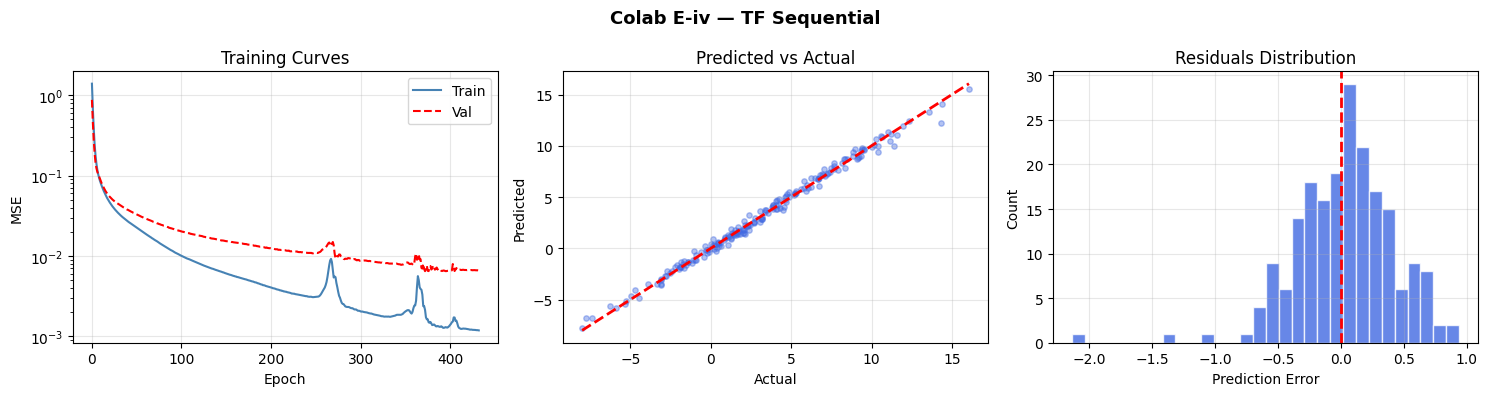

Test MSE: 0.0069 | MAE: 0.0626


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curves
axes[0].semilogy(history.history['loss'],label='Train',color='steelblue')
axes[0].semilogy(history.history['val_loss'],'r--',label='Val')
axes[0].set(title='Training Curves',xlabel='Epoch',ylabel='MSE'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Predicted vs actual
yp = model.predict(Xte, verbose=0)*y_std+y_mean
yt = Yte*y_std+y_mean
axes[1].scatter(yt,yp,alpha=0.4,s=15,color='royalblue')
mn,mx=yt.min(),yt.max(); axes[1].plot([mn,mx],[mn,mx],'r--',lw=2)
axes[1].set(title='Predicted vs Actual',xlabel='Actual',ylabel='Predicted'); axes[1].grid(alpha=0.3)

# Residuals
residuals = (yp - yt).flatten()
axes[2].hist(residuals,bins=30,color='royalblue',edgecolor='white',alpha=0.8)
axes[2].axvline(0,color='red',lw=2,linestyle='--')
axes[2].set(title='Residuals Distribution',xlabel='Prediction Error',ylabel='Count')
axes[2].grid(alpha=0.3)

plt.suptitle('Colab E-iv — TF Sequential', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

results = model.evaluate(Xte, Yte, verbose=0)
print(f'Test MSE: {results[0]:.4f} | MAE: {results[1]:.4f}')

## 🔁 Section 5 — Save, Reload, and All-Colab Comparison

In [7]:
# Save & reload — use .keras extension (required in Keras 3 / TF 2.16+)
model.save('colab_e4_model.keras')
reloaded = tf.keras.models.load_model('colab_e4_model.keras')

yp2 = reloaded.predict(Xte[:5], verbose=0)
yp1 = model.predict(Xte[:5], verbose=0)
print('Max difference between original and reloaded:', np.abs(yp2 - yp1).max())
print('Reloaded model produces identical predictions ✅')

Max difference between original and reloaded: 0.0
Reloaded model produces identical predictions ✅


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
